# Create base demand

This notebook processes a collection of load curves obtained from Svenska Kraftnät (currently the last 10 years 2014-2023 for which whole year data is available) and creates a base demand load curve for each concession area (SE1-SE4).

**2024-11-13**

- This version of the base demand is a rough alpha version.
- Currently the base demand is calculated as the average per hour of the 5 years 2019-2023.
- The extra day in the leap year 2020 is discarded. 
- Time series are not aligned which means that the weekday/weekend pattern is reduced.

In [1]:
# Import libraries

import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root_path = Path(globals()['_dh'][0]).resolve().parent.parent.parent
sys.path.append(str(root_path))

from paths import input_path

In [2]:
# Configuration

privacy = 'public'

In [3]:
# Read the files and build a data frame of 10 years data

lc_list = []

for year in range(2014,2024):
    lc = pd.read_excel(f"timvarden-{year}-01-12.xls", usecols=[0,1,2,3,4], skiprows=[0,1,2,3], names=['timestamp', 'SE1','SE2','SE3','SE4'])
    lc_list.append(lc)

load_curves = pd.concat(lc_list)

load_curves['timestamp'] = pd.to_datetime(load_curves['timestamp'], errors='coerce') # Parse timestamp as datetime (the date format is inconsistent between files)
load_curves.set_index('timestamp', inplace=True) # Use timestamp as indes
load_curves = -load_curves # Make load into demand by flipping the sign
load_curves = load_curves.sort_index() # Sort on date


In [4]:
# Some statistics on the data

yearly_totals = load_curves.groupby(load_curves.index.year).sum()

## Yearly totals in TWh
print(yearly_totals / 1_000_000)


                SE1        SE2        SE3        SE4
timestamp                                           
2014       5.942315  10.110045  49.465112  12.268637
2015       5.981563  10.006390  49.671319  12.302345
2016       6.935984   9.967463  50.079573  12.583194
2017       6.880942  10.032097  50.579162  12.561959
2018       7.626123  11.125990  52.824200  13.286592
2019       5.589418   4.811363  44.464246  11.824730
2020       5.617543   4.783703  43.757657  11.795324
2021       5.885763   5.186507  46.742885  12.496044
2022       6.321314   5.143016  46.301221  12.449482
2023       6.663950   5.191313  48.695396  13.052415


In [5]:
# Normalize load curves to sum up to 1 each year
norm_load_curves = load_curves.copy()

for col in norm_load_curves.columns:
    norm_load_curves[col] = load_curves[col].div(load_curves.groupby(load_curves.index.year)[col].transform('sum'))

In [6]:
# Calculate base demand load curve as the average of the last 5 years

second_half_norm_load_curves = norm_load_curves[(norm_load_curves.index >= '2019-01-01') & ~(norm_load_curves.index.strftime('%m-%d') == '02-29')]

base_load_curve = second_half_norm_load_curves.groupby([second_half_norm_load_curves.index.month, second_half_norm_load_curves.index.day, second_half_norm_load_curves.index.hour]).mean()

base_load_curve.index.names = ['month', 'day', 'hour']
base_load_curve = base_load_curve.reset_index()

base_load_curve['timestamp'] = pd.to_datetime(
    '2030-' + base_load_curve['month'].astype(str) + '-' + base_load_curve['day'].astype(str) + ' ' + base_load_curve['hour'].astype(str) + ':00:00'
)

base_load_curve.set_index('timestamp', inplace=True)
base_load_curve = base_load_curve.drop(columns=['month', 'day', 'hour'])

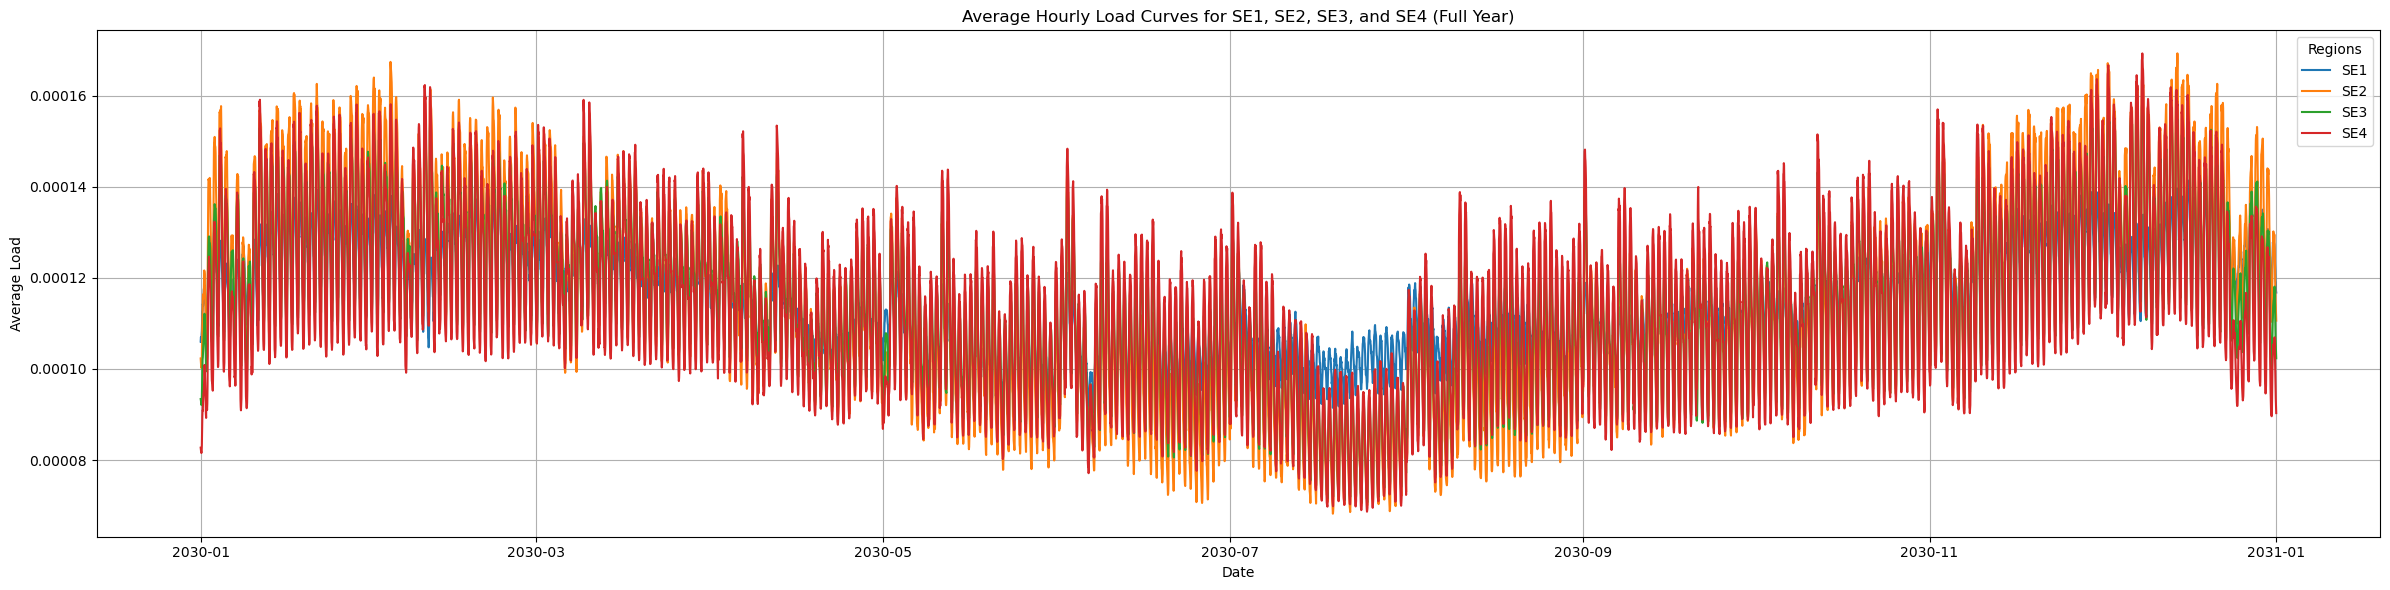

In [7]:
# Plotting the average_yearly DataFrame
plt.figure(figsize=(24, 6))

for column in base_load_curve.columns:
    plt.plot(base_load_curve.index, base_load_curve[column], label=column)

# Adding labels, title, and legend
plt.title("Average Hourly Load Curves for SE1, SE2, SE3, and SE4 (Full Year)")
plt.xlabel("Date")
plt.ylabel("Average Load")
plt.legend(title="Regions")
plt.grid(visible=True)
plt.tight_layout()

plt.show()

In [8]:
base_load_curve.to_csv(input_path / privacy / 'base_demand' / 'base_load_curve.csv')